In [1]:
# plotting
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# calculation
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

In this notebook: Creating ground-to-300 hPa OMI/MLS Trop. Ozone climatology from NASA Goddard (https://acd-ext.gsfc.nasa.gov/Data_services/cloud_slice/) and saving as monthly files/plotting purposes

In [2]:
dataset = xr.open_dataset('/glade/u/home/mvoncyga/SOARS_2025/input/omi_mls/tco300_omimls_oct2004_to_dec2024_1by1.nc')

So now it is time for some data cleaning, there should not be any negative values in the data

In [3]:
ozone = dataset["TropoO3"]
cleaned_ozone_dataset = ozone.where(ozone >= 0)
dataset["TropoO3"] = cleaned_ozone_dataset

In [4]:
ozone = cleaned_ozone_dataset 

# adding month from attributes to coordinate
month = ozone.attrs['Month'].split(',')
first_month = month[0]                              # October 2004
last_month = month[-1].replace(' ', '')             # December 2024

start_date = datetime.strptime(first_month, "%b%Y")
end_date = datetime.strptime(last_month, "%b%Y")

time_coords = pd.date_range(start=start_date, end=end_date, freq='MS')

In [5]:
# renaming and assigning/removing dimensions
ozone = ozone.assign_coords(time=('months', time_coords))
ozone = ozone.rename({"time": "yearmonth",'y_elements': 'latitude', 'x_elements': 'longitude'})
ozone = ozone.swap_dims({'months': 'yearmonth'})

Subsetting necessary months. This is January 2005 - December 2024

In [6]:
#### Select desired date range
ozone_subsetted = ozone.sel(yearmonth=slice("2005-01-01", "2024-12-01"))

In [7]:
ozone_mean_subsetted = ozone_subsetted.assign_attrs(_FillValue="-999",name="Tropospheric Ozone Mean, Ground to 300 hPa", latitude="-75.5, -59.5, -58.5, ..., 59.5, 75.5")
ozone_stdev_subsetted = ozone_subsetted.assign_attrs(_FillValue="-999",name="Tropospheric Ozone STDEV, Ground to 300 hPa", latitude="-75.5, -59.5, -58.5, ..., 59.5, 75.5")

del ozone_mean_subsetted.attrs['Month']
del ozone_stdev_subsetted.attrs['Month']

In [8]:
# adding lat/lon from attributes to coordinates
lat_coords = ozone_subsetted.attrs['latitude'].split(',')
first_lat = float(lat_coords[0])
last_lat = float(lat_coords[-1])

lon_coords = ozone_subsetted.attrs['longitude'].split(',')
first_lon = float(lon_coords[0])
last_lon = float(lon_coords[-1])

lon_coords = np.arange(first_lon, 180.5, 1)
lat_coords = np.arange(first_lat,90.5, 1)

ozone_mean_subsetted = ozone_mean_subsetted.assign_coords(
    longitude=('longitude', lon_coords),
    latitude=('latitude', lat_coords)
)

ozone_stdev_subsetted = ozone_stdev_subsetted.assign_coords(
    longitude=('longitude', lon_coords),
    latitude=('latitude', lat_coords)
)

In [9]:
# grouping by calendar month
monthly_mean = ozone_mean_subsetted.groupby('yearmonth.month').mean('yearmonth')
monthly_stdev = ozone_stdev_subsetted.groupby('yearmonth.month').std('yearmonth') # group it with means

# grouping by season
seasonal_mean = ozone_mean_subsetted.groupby('yearmonth.season').mean('yearmonth')
seasonal_stdev = ozone_stdev_subsetted.groupby('yearmonth.season').std('yearmonth')

Now truncate to 75°S-75°N, add fill value, and save as NETCDF4 files

In [10]:
mean_netcdf_dataset = monthly_mean.sel(latitude=slice(-75.5,75.5))

stdev_netcdf_dataset = monthly_stdev.sel(latitude=slice(-75.5,75.5))

In [11]:
mean_netcdf_dataset.fillna(-999)

<xarray.DataArray 'TropoO3' (month: 12, latitude: 152, longitude: 360)> Size: 3MB
array([[[  16.610928 ,   16.635612 ,   16.655369 , ...,   15.158942 ,
           15.331881 ,   15.250627 ],
        [  16.772608 ,   16.803436 ,   16.927177 , ...,   15.190026 ,
           15.270223 ,   15.335663 ],
        [  16.812292 ,   16.900846 ,   17.089277 , ...,   15.086402 ,
           15.072547 ,   15.1386595],
        ...,
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ]],

       [[  17.7043   ,   17.887877 ,   18.236958 , ...,   16.12961  ,
           15.977057 ,   15.949893 ],
        [  17.711636 ,   17.826044 ,   18.168581 , ...,   15.678398 ,
           15.762339 ,   15.831459 ],
        [  18.12853  ,   18.19189  ,   18.261696 , ...,   15.629116 ,
           15.709588 ,   15.715805 ],
...
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ]],

       [[  21.306644 ,   21.534334 ,   22.171347 , ...,   17.564814 ,
           17.567068 ,   17.449982 ],
        [  21.72311  ,   21.74591  ,   22.105104 , ...,   17.584597 ,
           17.333443 ,   17.199173 ],
        [  21.782862 ,   22.088297 ,   22.345867 , ...,   16.959076 ,
           16.663982 ,   16.613573 ],
        ...,
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ],
        [-999.       , -999.       , -999.       , ..., -999.       ,
         -999.       , -999.       ]]], dtype=float32)
Coordinates:
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * latitude   (latitude) float64 1kB -75.5 -74.5 -73.5 -72.5 ... 73.5 74.5 75.5
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:       Dobson Units
    name:        Tropospheric Ozone Mean, Ground to 300 hPa
    latitude:    -75.5, -59.5, -58.5, ..., 59.5, 75.5
    longitude:   -179.5, -178.5, ..., 179.5
    _FillValue:  -999

In [12]:
#mean_netcdf_dataset.to_netcdf(path="/glade/u/home/mvoncyga/SOARS_2025/data/OMI_MLS_climatology_files/OMI_MLS_300hpa_monthly_mean_2005_2024.nc",format="NETCDF4")

In [13]:
stdev_netcdf_dataset.fillna(-999)

<xarray.DataArray 'TropoO3' (month: 12, latitude: 152, longitude: 360)> Size: 3MB
array([[[ 1.4883140e+00,  1.2546980e+00,  9.9517590e-01, ...,
          1.5512474e+00,  1.4806232e+00,  1.4384158e+00],
        [ 1.4383551e+00,  1.3418806e+00,  1.3841609e+00, ...,
          1.3236319e+00,  1.2694534e+00,  1.1799153e+00],
        [ 1.5286313e+00,  1.4873599e+00,  1.6533293e+00, ...,
          1.3105993e+00,  1.2243972e+00,  1.2203419e+00],
        ...,
        [-9.9900000e+02, -9.9900000e+02, -9.9900000e+02, ...,
         -9.9900000e+02, -9.9900000e+02, -9.9900000e+02],
        [-9.9900000e+02, -9.9900000e+02, -9.9900000e+02, ...,
         -9.9900000e+02, -9.9900000e+02, -9.9900000e+02],
        [-9.9900000e+02, -9.9900000e+02, -9.9900000e+02, ...,
         -9.9900000e+02, -9.9900000e+02, -9.9900000e+02]],

       [[ 1.8764802e+00,  2.0557868e+00,  1.7273605e+00, ...,
          1.8665925e+00,  1.7497228e+00,  1.7382605e+00],
        [ 1.9759082e+00,  2.1817517e+00,  2.0256555e+00, ...,
          1.7159221e+00,  1.7430605e+00,  1.8374991e+00],
        [ 2.2520952e+00,  2.3799927e+00,  2.2490752e+00, ...,
          1.8454915e+00,  1.8404026e+00,  1.7334585e+00],
...
        [-9.9900000e+02, -9.9900000e+02, -9.9900000e+02, ...,
         -9.9900000e+02, -9.9900000e+02, -9.9900000e+02],
        [-9.9900000e+02, -9.9900000e+02, -9.9900000e+02, ...,
         -9.9900000e+02, -9.9900000e+02, -9.9900000e+02],
        [-9.9900000e+02, -9.9900000e+02, -9.9900000e+02, ...,
         -9.9900000e+02, -9.9900000e+02, -9.9900000e+02]],

       [[ 3.6807060e+00,  4.0592704e+00,  5.1392522e+00, ...,
          1.8333876e+00,  1.7312202e+00,  1.6018672e+00],
        [ 3.8299758e+00,  4.0318031e+00,  4.6413307e+00, ...,
          1.3951125e+00,  1.4749901e+00,  1.4831877e+00],
        [ 4.2063017e+00,  4.3421850e+00,  4.6122446e+00, ...,
          1.5254247e+00,  1.1890492e+00,  1.3278961e+00],
        ...,
        [-9.9900000e+02, -9.9900000e+02, -9.9900000e+02, ...,
         -9.9900000e+02, -9.9900000e+02, -9.9900000e+02],
        [-9.9900000e+02, -9.9900000e+02, -9.9900000e+02, ...,
         -9.9900000e+02, -9.9900000e+02, -9.9900000e+02],
        [-9.9900000e+02, -9.9900000e+02, -9.9900000e+02, ...,
         -9.9900000e+02, -9.9900000e+02, -9.9900000e+02]]], dtype=float32)
Coordinates:
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * latitude   (latitude) float64 1kB -75.5 -74.5 -73.5 -72.5 ... 73.5 74.5 75.5
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:       Dobson Units
    name:        Tropospheric Ozone STDEV, Ground to 300 hPa
    latitude:    -75.5, -59.5, -58.5, ..., 59.5, 75.5
    longitude:   -179.5, -178.5, ..., 179.5
    _FillValue:  -999

In [14]:
#stdev_netcdf_dataset.to_netcdf(path="/glade/u/home/mvoncyga/SOARS_2025/data/OMI_MLS_climatology_files/OMIMLS_300hpa_monthly_stdev_2005_2024.nc",format="NETCDF4")

Plotting

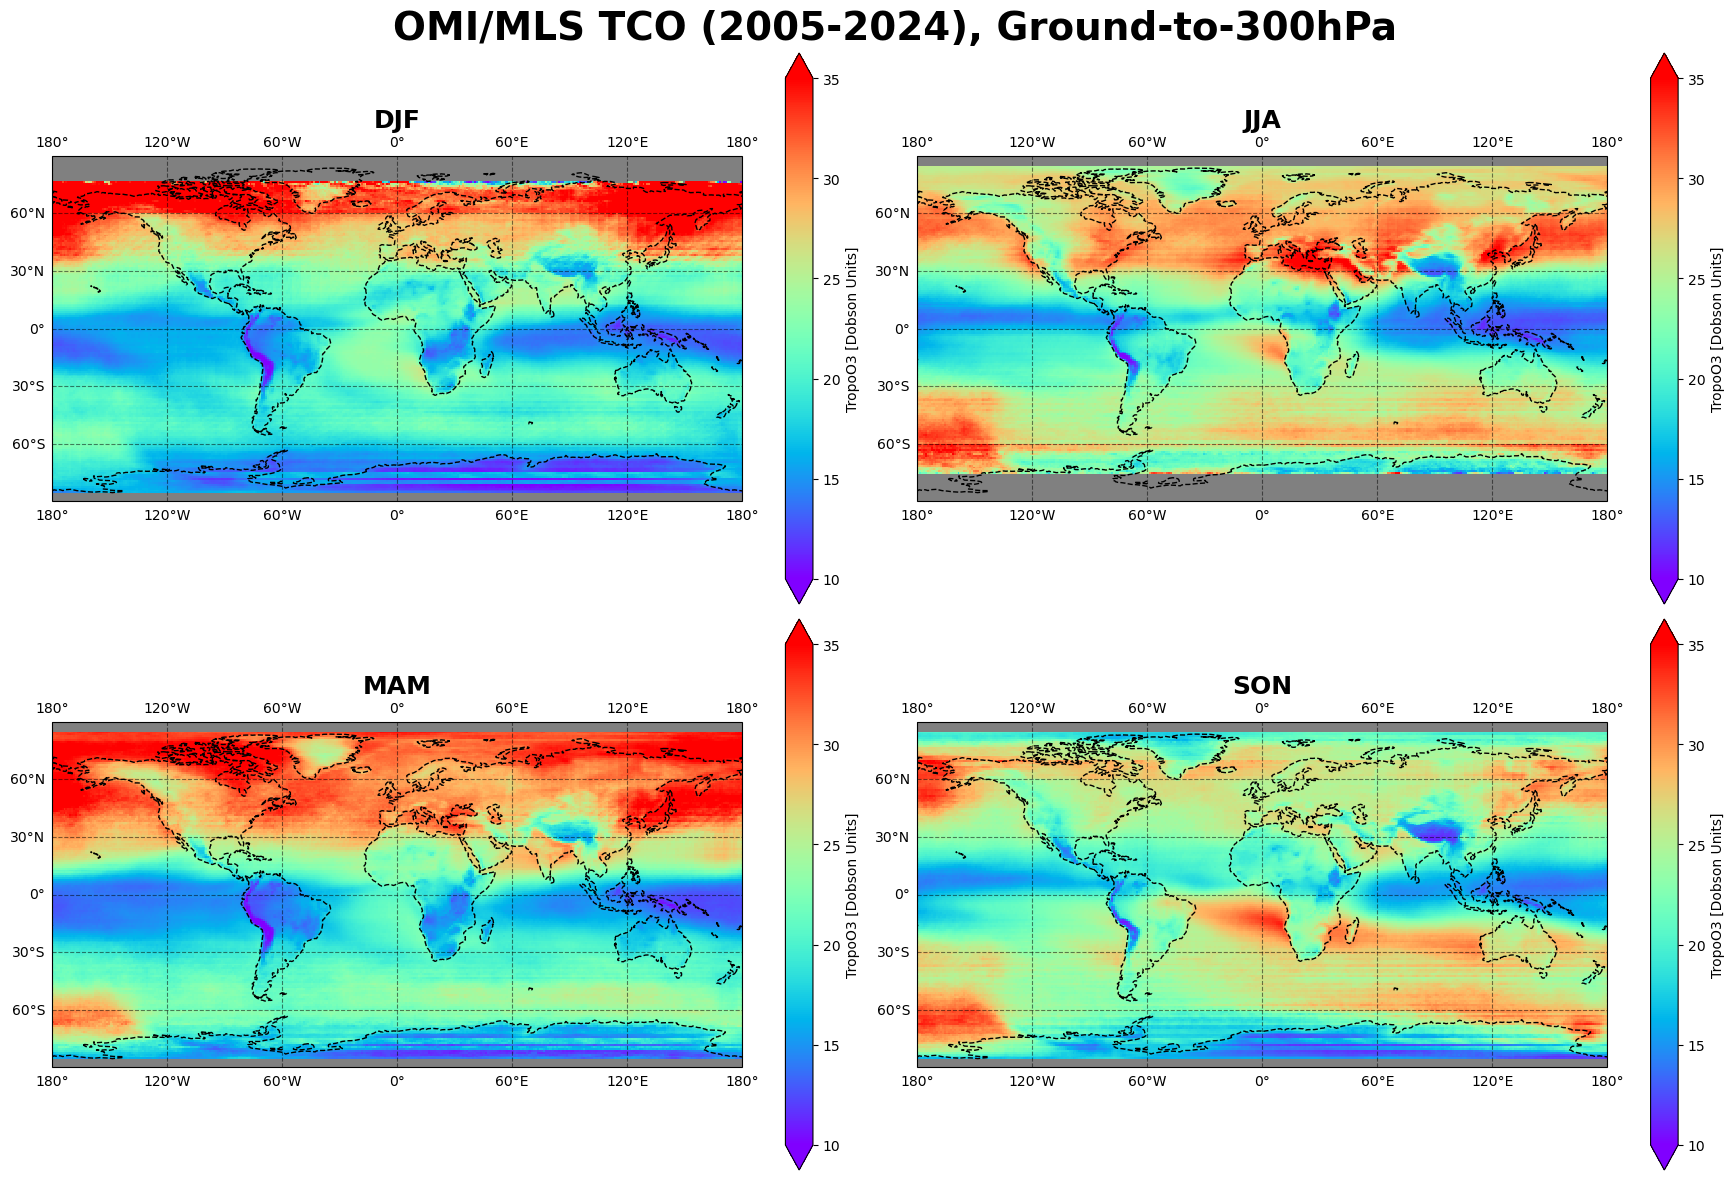

In [15]:
seasonal_list = ['DJF', 'JJA', 'MAM', 'SON']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

for i, ax in enumerate(axes.ravel()):
    #ax.spines[axis].set_linewidth(100.5)
    seasonal_mean[i].plot(ax=ax,transform=ccrs.PlateCarree(central_longitude=0), vmin=10, vmax=35, extend='both', cmap='rainbow')
    ax.set_global()
    ax.set_facecolor('gray')
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.right_labels = False
    

    ax.add_feature(cfeature.COASTLINE, linestyle='--')
    ax.set_title(f'{seasonal_list[i]}', fontsize=18, fontweight='bold')
    fig.suptitle('OMI/MLS TCO (2005-2024), Ground-to-300hPa', fontsize=28, fontweight='bold')
    plt.tight_layout()


#plt.savefig("/glade/u/home/mvoncyga/SOARS_2025/figures/climatology_omi_mls/300hpa_seasonal")
plt.show()

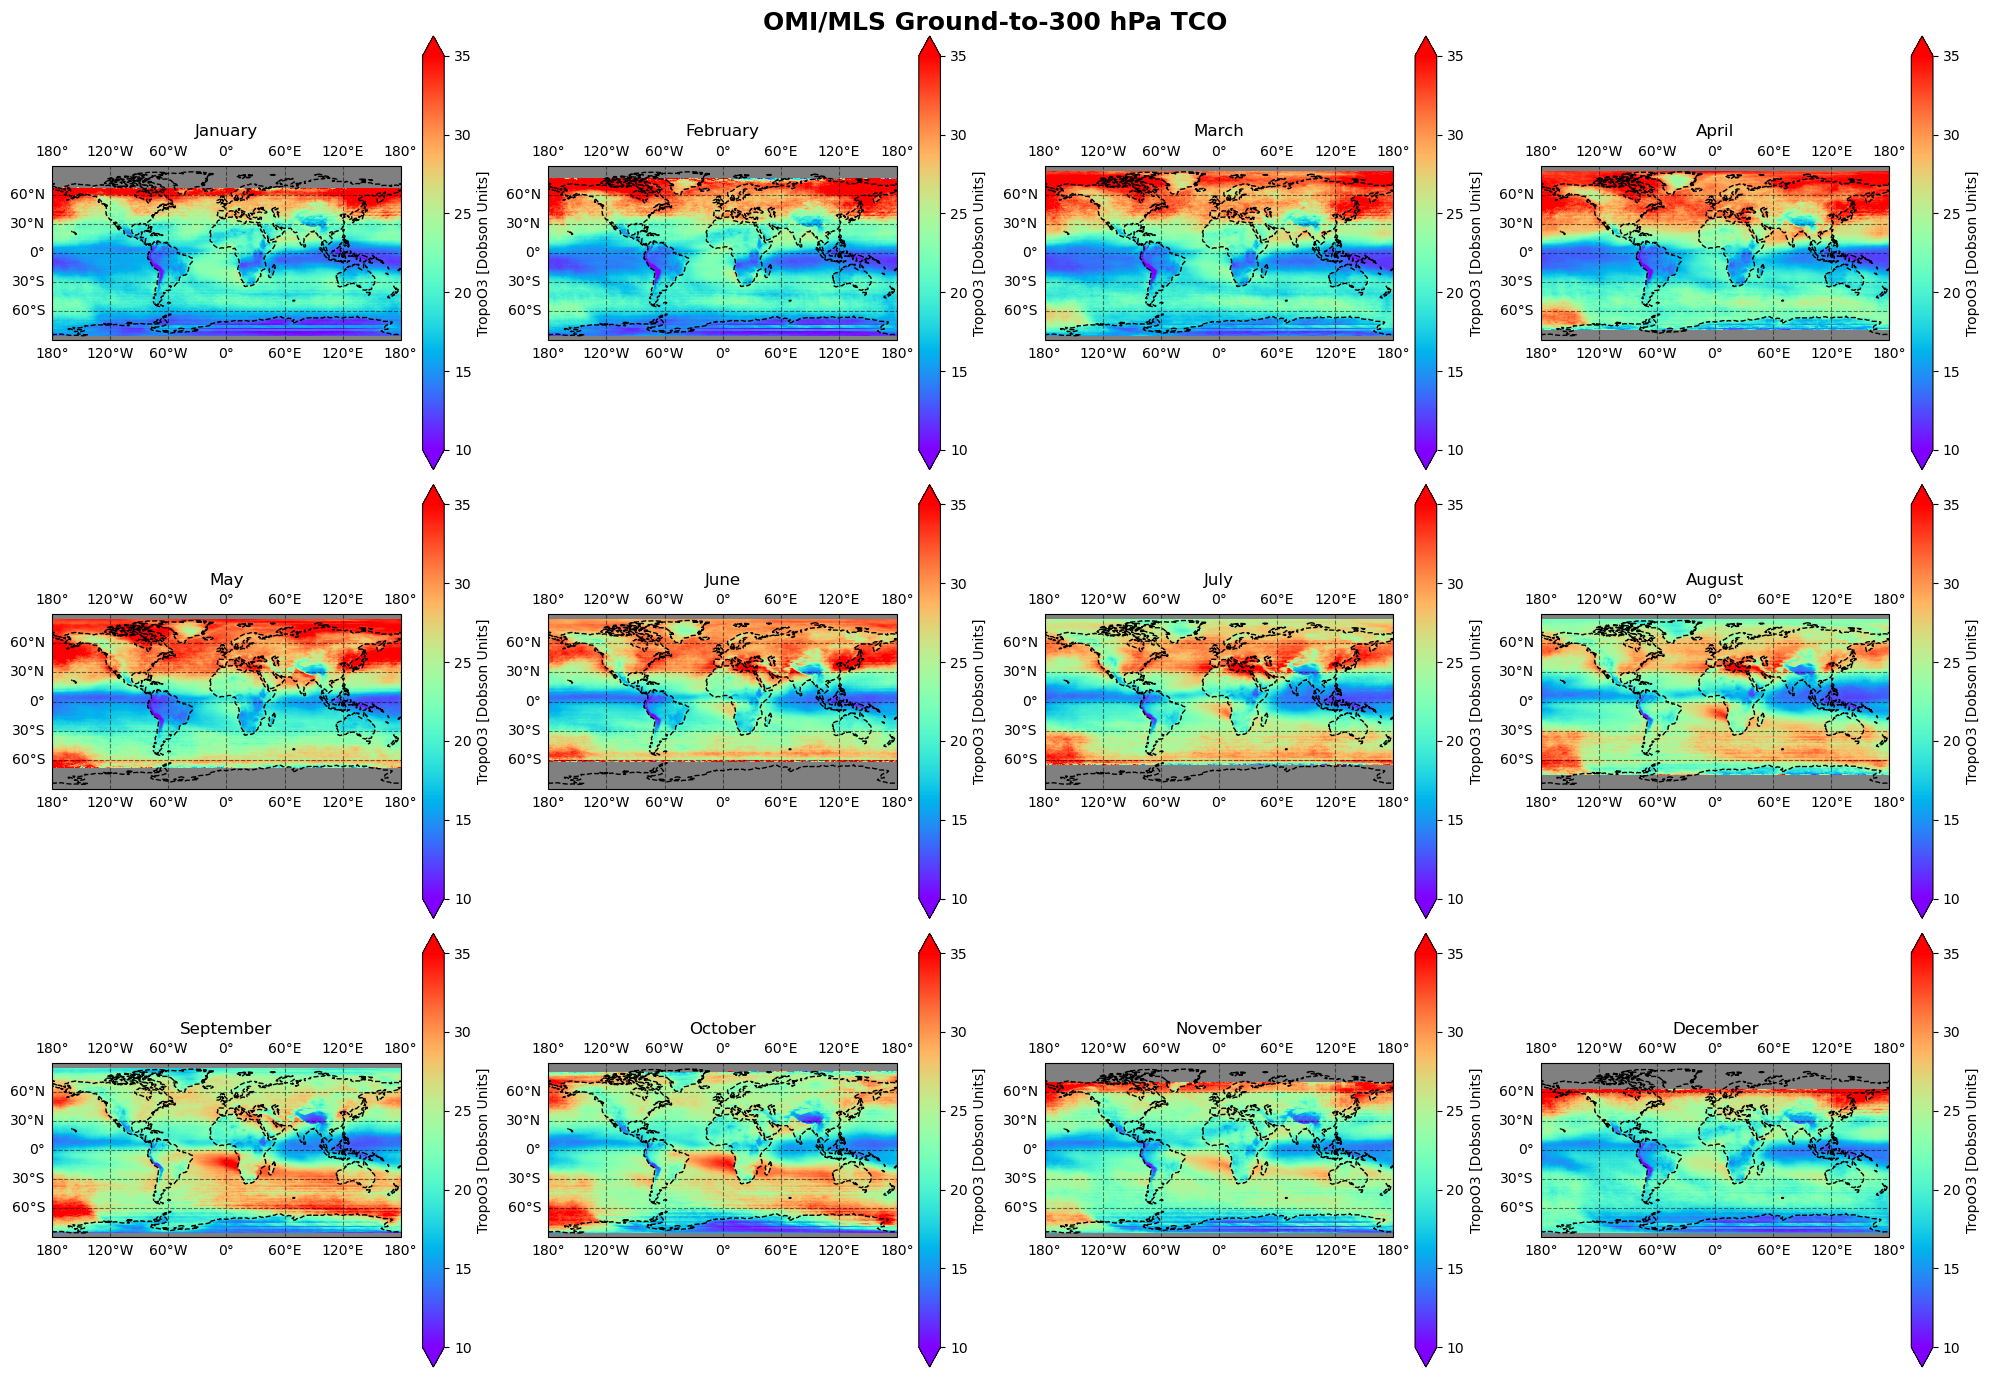

In [16]:
month_list = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 14), subplot_kw=dict(projection=ccrs.PlateCarree()))

for i, ax in enumerate(axes.ravel()):
    monthly_mean[i].plot(ax=ax, transform=ccrs.PlateCarree(), extend='both', vmin=10, vmax=35, cmap='rainbow')
    ax.set_facecolor('gray')
    ax.set_global()
    gl = ax.gridlines(draw_labels=True, color='black', alpha=0.5, linestyle='--')
    gl.right_labels = False

    ax.add_feature(cfeature.COASTLINE, linestyle='--')
    ax.set_title(f'{month_list[i]}')
    plt.suptitle("OMI/MLS Ground-to-300 hPa TCO", 
                 fontsize=18, fontweight='bold')
    plt.tight_layout()

#plt.savefig("/glade/u/home/mvoncyga/SOARS_2025/figures/climatology_omi_mls/300hpa_monthly")
plt.show()